# Ultrasoft and PAW pseudopotentials

Norm conservation is what makes a pseudopotential expensive: the pseudo-orbital has to
carry the same charge as the all-electron one inside the core, which fixes how smooth it
can be. Ultrasoft drops that constraint and puts the missing charge back as an
**augmentation charge** $Q_{ij}(r)$; PAW keeps a full radial description of each sphere
on top. Both match Quantum ESPRESSO here to **3e-9 Ry or better**.

The density gains a second piece that lives only inside the spheres, and the eigenproblem
gains an overlap:

$$n(\mathbf r) = \sum_{n\mathbf k} f_{n\mathbf k}\,|\psi_{n\mathbf k}(\mathbf r)|^2
  \;+\; \sum_{I,ij} \rho^I_{ij}\,Q^I_{ij}(\mathbf r),
\qquad
\rho^I_{ij} = \sum_{n\mathbf k} f_{n\mathbf k}
  \langle\psi_{n\mathbf k}|\beta^I_i\rangle\langle\beta^I_j|\psi_{n\mathbf k}\rangle$$

$$\hat S = 1 + \sum_{I,ij} q^I_{ij}\,|\beta^I_i\rangle\langle\beta^I_j|,
\qquad q^I_{ij} = \int Q^I_{ij}(\mathbf r)\,d\mathbf r$$

The payoff is the cutoff: the same accuracy on oxygen or a transition metal at a third of
the plane waves a norm-conserving dataset would need.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from pypresso import Calculator
from pypresso.io import read_qe_output
from pypresso.pseudo import read_upf

CASES, PSEUDO = Path("../tests/data/qe"), Path("../tests/data/pseudo")


def load(case):
    return Calculator.from_file(CASES / f"{case}.in", pseudo_dir=PSEUDO,
                                announce=False)


def reference(case):
    return read_qe_output(CASES / f"reference.out.{case}")


nc = read_upf(PSEUDO / "Si.pz-vbc.UPF")
us = read_upf(PSEUDO / "Si.pz-n-rrkjus_psl.0.1.UPF")
paw = read_upf(PSEUDO / "Si.pz-n-kjpaw_psl.0.1.UPF")
for p in (nc, us, paw):
    print("%-32s %-5s ultrasoft=%-5s PAW=%-5s projectors=%s nh=%d"
          % (p.path.name, p.pseudo_type, p.is_ultrasoft, p.is_paw,
             [b.l for b in p.projectors], p.nh))

Si.pz-vbc.UPF                    NC    ultrasoft=False PAW=False projectors=[0, 1] nh=4
Si.pz-n-rrkjus_psl.0.1.UPF       USPP  ultrasoft=True  PAW=False projectors=[0, 0, 1, 1] nh=8
Si.pz-n-kjpaw_psl.0.1.UPF        PAW   ultrasoft=True  PAW=True  projectors=[0, 0, 1, 1] nh=8


## Two grids, and a charge that is short-ranged

The wavefunctions stay smooth, so they keep the cutoff they always had; the augmentation
charge is sharp and needs a denser one. That is the whole meaning of `ecutrho`: a
**smooth** grid carrying the wavefunctions and a **dense** grid carrying the density, with
the ratio between them set by how localised $Q_{ij}(r)$ is.

dual = ecutrho/ecutwfc = 8
                           pypresso             Quantum ESPRESSO
dense      9185 G  FFT   (32, 32, 32)     9185 G  FFT   (32, 32, 32)
smooth     3143 G  FFT   (24, 24, 24)     3143 G  FFT   (24, 24, 24)
smooth G-vectors are the first 3143 dense ones: True


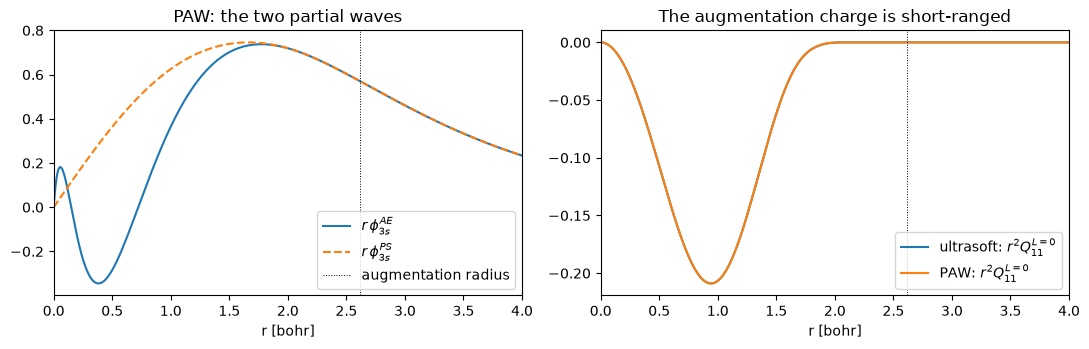

In [2]:
calc = load("si2-us")
basis, ref = calc.calculation.basis, reference("si2-us")

print("dual = ecutrho/ecutwfc = %g"
      % (calc.system.ecutrho / calc.system.ecutwfc))
print("%-8s %26s   %26s" % ("", "pypresso", "Quantum ESPRESSO"))
print("%-8s %6d G  FFT %14s   %6d G  FFT %14s"
      % ("dense", basis.dense.ngm, basis.dense.grid, ref.ngm_dense, ref.fft_dense))
print("%-8s %6d G  FFT %14s   %6d G  FFT %14s"
      % ("smooth", basis.smooth.ngm, basis.smooth.grid, ref.ngm_smooth, ref.fft_smooth))
print("smooth G-vectors are the first %d dense ones: %s"
      % (basis.smooth.ngm,
         np.array_equal(np.asarray(basis.smooth.miller),
                        np.asarray(basis.dense.miller)[: basis.smooth.ngm])))

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
iraug = paw.paw.cutoff_index
axes[0].plot(paw.r, paw.paw.ae_wfc[0], label=r"$r\,\phi^{AE}_{3s}$")
axes[0].plot(paw.r, paw.paw.ps_wfc[0], "--", label=r"$r\,\phi^{PS}_{3s}$")
axes[0].axvline(paw.r[iraug - 1], color="k", lw=0.7, ls=":", label="augmentation radius")
axes[0].set_xlim(0, 4); axes[0].set_xlabel("r [bohr]"); axes[0].legend()
axes[0].set_title("PAW: the two partial waves")
for label, pp in (("ultrasoft", us), ("PAW", paw)):
    axes[1].plot(pp.r, pp.augmentation.qfuncl[0, 0, 0],
                 label=r"%s: $r^2Q^{L=0}_{11}$" % label)
axes[1].axvline(paw.r[iraug - 1], color="k", lw=0.7, ls=":")
axes[1].set_xlim(0, 4); axes[1].set_xlabel("r [bohr]"); axes[1].legend()
axes[1].set_title("The augmentation charge is short-ranged")
fig.tight_layout()

## The identity the overlap operator buys

Without norm conservation $\langle\psi|\psi\rangle$ is no longer the charge. The
eigenproblem becomes generalised, $H\psi = \varepsilon S\psi$, and the augmentation charge
is added back to the density on the dense grid. Get either half wrong and the integrated
density stops being the number of electrons, which is a sharper test than any energy
because it is exact rather than approximate.

In [3]:
cases = {case: load(case)
         for case in ("si2-nc-dual8", "si2-us", "si2-paw", "si8-paw")}
results = {case: c.get_scf(conv_thr=1e-10, max_iterations=80)
           for case, c in cases.items()}

print("%-16s %5s %16s %8s" % ("case", "iters", "integral of rho", "nelec"))
for case, r in results.items():
    system, pseudos = cases[case].system, cases[case].pseudos
    rho = np.asarray(r.total_density)
    print("%-16s %5d %16.12f %8.1f"
          % (case, r.iterations,
             float(np.sum(rho)) * float(system.cell.volume) / rho.size,
             sum(pseudos[t].z_valence for t in system.structure.types)))

case             iters  integral of rho    nelec
si2-nc-dual8         7   8.000000000000      8.0
si2-us               9   8.000000000000      8.0
si2-paw              8   8.000000000000      8.0
si8-paw              8  32.000000000000     32.0


## Against Quantum ESPRESSO

The screened coefficients $D_{ij}$ are the other thing that changes: with an augmentation
charge they stop being constants read from the file and pick up
$\int V_{\rm eff}(\mathbf r)\, Q_{ij}(\mathbf r)\, d\mathbf r$, so they follow the
potential through the SCF. PAW adds its one-centre terms on top, a radial Poisson solve
and a spherical quadrature inside each sphere, which is what lets it reconstruct
all-electron quantities the pseudo density has thrown away.

In [4]:
print("%-16s %16s %16s %12s" % ("case", "pypresso (Ry)", "QE 7.5 (Ry)", "difference"))
for case, r in results.items():
    q = reference(case)
    print("%-16s %16.8f %16.8f %12.1e"
          % (case, r.total_energy, q.total_energy, r.total_energy - q.total_energy))

r = results["si2-paw"]
q = reference("si2-paw")
print("\nsi2-paw, term by term:")
for term, value in q.energy_terms.items():
    print("  %-18s %16.8f %16.8f %12.1e"
          % (term, r.energy_terms[term], value, r.energy_terms[term] - value))

for case in ("si2-us", "si2-paw"):
    r = results[case]
    theirs = reference(case).eigenvalues[0][:, : r.eigenvalues.shape[1]]
    print("\n%s: max |pypresso - QE| = %.3f meV over %d eigenvalues"
          % (case, np.abs(r.eigenvalues_ev - theirs).max() * 1000, theirs.size))

case                pypresso (Ry)      QE 7.5 (Ry)   difference
si2-nc-dual8         -15.79449489     -15.79449489     -9.2e-10
si2-us               -22.75348130     -22.75348130     -2.4e-09
si2-paw              -89.27493665     -89.27493665     -2.9e-09
si8-paw             -357.09973538    -357.09973538     -2.3e-09

si2-paw, term by term:
  one-electron             5.90316626       5.90316889     -2.6e-06
  hartree                  1.09671862       1.09671431      4.3e-06
  xc                     -12.19555356     -12.19555167     -1.9e-06
  ewald                  -16.89975860     -16.89975860     -2.1e-09
  one_center_paw         -67.17950937     -67.17950958      2.1e-07

si2-us: max |pypresso - QE| = 0.053 meV over 8 eigenvalues

si2-paw: max |pypresso - QE| = 0.041 meV over 8 eigenvalues


The one-centre term is 75% of the total for PAW, and most of *it* is a constant: the
exchange-correlation energy of the frozen core, which the dataset fixes and no calculation
changes.

---
The tests behind this notebook: `tests/regression/test_uspp.py`.